In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from pysus import SINASC
sinasc = SINASC().load()

In [7]:
sinasc.groups

{'DN': 'Declarações de Nascidos Vivos',
 'DNR': 'Dados dos Nascidos Vivos por UF de residência'}

In [8]:
files = sinasc.get_files("DN",uf="TO")

In [9]:
parquet = sinasc.download(files)

DNTO2022.parquet: 100%|██████████| 25.3k/25.3k [00:01<00:00, 13.4kB/s]


In [10]:
lista_df = [f.to_dataframe() for f in parquet]
to = pd.concat(lista_df, ignore_index=True)

In [30]:
to['IDADEMAE'] = pd.to_numeric(to['IDADEMAE'], errors='coerce')

In [34]:
busca = to[(to['DTNASC'].astype(str).str.endswith('2022')) & (to['IDADEMAE']>=20) & (to['IDADEMAE']<=30)]
print(f"total de nascidos em 2022 com mãe entre os 20 e 30 anos: {len(busca)}")
display(busca)

total de nascidos em 2022 com mãe entre os 20 e 30 anos: 12381


,contador,LOCNASC,CODMUNNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,CODMUNRES,...,CODUFNATU,TPNASCASSI,ESCMAEAGR1,DTRECORIGA,TPFUNCRESP,TPDOCRESP,DTDECLARAC,PARIDADE,KOTELCHUCK,CONTADOR
655389,<NA>,1,150010,29.0,5,5,411010,01,00,171610,...,15,1,08,,2,3,10012022,1,5,63627
655391,<NA>,1,150270,24.0,5,4,516205,00,03,171665,...,17,1,06,,2,3,05012022,1,2,95404
655392,<NA>,1,150270,25.0,5,4,,01,00,170600,...,17,2,12,,2,3,09012022,1,5,95414
655393,<NA>,1,150270,26.0,2,5,239415,00,01,171180,...,17,1,08,,2,3,26012022,1,5,95441
655394,<NA>,1,150270,20.0,2,4,999992,00,00,171180,...,15,1,06,,2,3,20012022,0,9,95459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677932,<NA>,1,521800,30.0,2,4,999992,02,01,172097,...,52,1,06,,5,4,24122022,1,5,2537728
677933,<NA>,1,530010,24.0,1,5,,00,00,170310,...,53,1,07,,,0,03072022,0,5,2537963
677934,<NA>,1,530010,21.0,1,2,999992,01,00,170700,...,17,1,01,,2,3,17102022,1,3,2549348
677935,<NA>,1,530010,25.0,2,5,241005,00,00,170070,...,29,1,08,,5,4,08092022,0,5,2549370


In [36]:
to['QTDFILMORT'] = pd.to_numeric(to['QTDFILMORT'], errors='coerce')

In [39]:
busca = to[(to['QTDFILMORT']>=1)]
print(f"Quantidade de mães que deram a luz que já tinham pelo menos 1 filho morto: {len(busca)}")
display(busca)

Quantidade de mães que deram a luz que já tinham pelo menos 1 filho morto: 104895


,contador,LOCNASC,CODMUNNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,CODMUNRES,...,CODUFNATU,TPNASCASSI,ESCMAEAGR1,DTRECORIGA,TPFUNCRESP,TPDOCRESP,DTDECLARAC,PARIDADE,KOTELCHUCK,CONTADOR
35,36,1,5204904,24.0,,8,,,1.0,1702406,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
39,40,1,5204904,24.0,,7,,03,2.0,1702703,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
42,43,1,5218003,29.0,,8,,,1.0,1721000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
51,52,1,1716604,35.0,,6,,03,1.0,1716604,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64,65,1,5218003,34.0,,1,,09,1.0,1702000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677904,<NA>,1,521800,30.0,2,5,231315,01,1.0,171575,...,52,1,08,,5,5,09082022,1,4,2522702
677913,<NA>,1,520490,30.0,2,4,,02,1.0,170555,...,17,1,06,,2,3,14102022,1,4,2526999
677923,<NA>,1,520870,32.0,2,5,241005,00,1.0,170210,...,52,1,08,,2,3,17122022,1,5,2534908
677924,<NA>,1,522160,22.0,1,3,999992,03,1.0,171150,...,52,1,03,,2,3,01012023,1,2,2535233


In [43]:
busca = to[(to['DTNASC'].astype(str).str.endswith('2020')) & (to['QTDFILMORT']>=2)]
print(f"Quantidade de mães que deram a luz em 2020 que já tinham pelo menos 2 filhos mortos: {len(busca)}")
display(busca)

Quantidade de mães que deram a luz em 2020 que já tinham pelo menos 2 filhos mortos: 991


,contador,LOCNASC,CODMUNNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,CODMUNRES,...,CODUFNATU,TPNASCASSI,ESCMAEAGR1,DTRECORIGA,TPFUNCRESP,TPDOCRESP,DTDECLARAC,PARIDADE,KOTELCHUCK,CONTADOR
607929,<NA>,1,150810,37.0,5,3,,06,2.0,172030,...,15,1,02,,5,4,09052020,1,3,128105
607950,<NA>,1,170200,21.0,5,3,999992,02,2.0,171884,...,52,2,11,,2,4,03052020,1,2,137718
607961,<NA>,1,170210,19.0,1,4,622020,00,2.0,172208,...,15,2,04,,5,5,02012020,1,4,137731
608006,<NA>,1,170210,22.0,4,4,622020,01,2.0,171630,...,17,1,06,,5,5,05012020,1,5,137781
608008,<NA>,1,170210,34.0,1,4,521135,03,2.0,171488,...,23,1,06,,5,5,06012020,1,5,137783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631437,<NA>,1,210530,32.0,1,3,622105,03,2.0,170290,...,,,,,,,,1,9,1587180
631445,<NA>,1,210530,24.0,1,3,999992,03,3.0,172080,...,,,,,,,,1,9,1587341
631533,<NA>,1,510785,33.0,5,4,999992,03,2.0,171190,...,17,1,06,,2,4,04102020,1,5,2659117
631625,<NA>,1,521800,33.0,2,4,999992,01,2.0,171575,...,11,1,06,,2,4,02122020,1,5,2700040


In [15]:
def gerar_tabela_presenca(df, coluna_data):
    df = df.copy()

    df['ANO'] = df[coluna_data].str[-4:].astype(int)
    anos = sorted(df['ANO'].unique())

    colunas = [col for col in df.columns if col != coluna_data and col != 'ANO']

    resultado = pd.DataFrame(index=colunas, columns=anos)

    for col in colunas:
        for ano in anos:
            subset = df[df['ANO'] == ano]
            if subset[col].notna().any():
                resultado.loc[col, ano] = 1
            else:
                resultado.loc[col, ano] = 0
    resultado = resultado.astype(int)
    return resultado

In [28]:
def heatmap(df):
    plt.figure(figsize=(12,10))

    sns.heatmap(
        df,
        cmap="coolwarm_r",
        cbar=True,
        linewidths=0.5,
        yticklabels=True
    )
    plt.yticks(fontsize=6)

    plt.title("Presença de atributos por ano")
    plt.xlabel("Ano")
    plt.ylabel("Atributos")

    plt.tight_layout()
    plt.show()

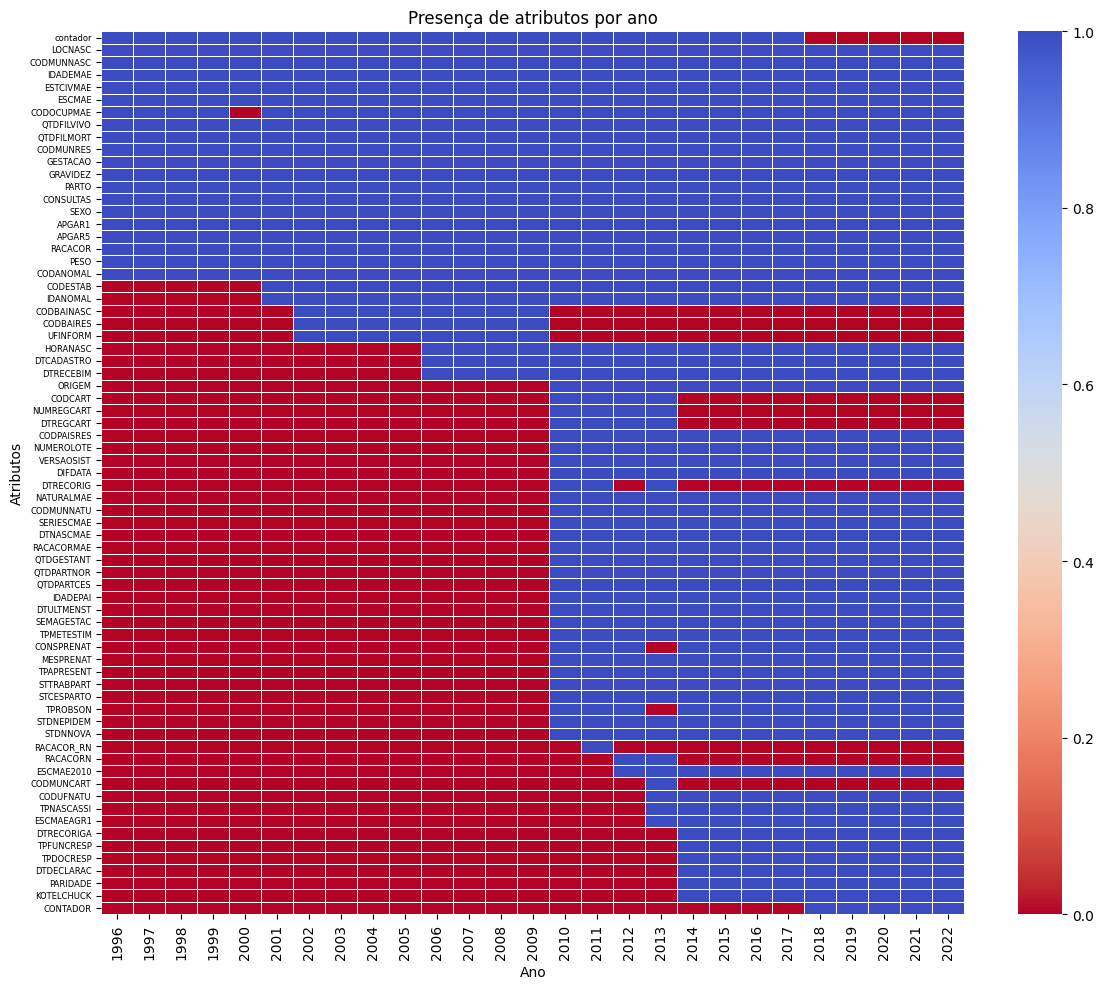

In [29]:
to_presenca = gerar_tabela_presenca(to, 'DTNASC')
heatmap(to_presenca)

In [20]:
display(to_presenca)

,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
contador,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,0,0,0,0
LOCNASC,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CODMUNNASC,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
IDADEMAE,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ESTCIVMAE,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TPDOCRESP,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
DTDECLARAC,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
PARIDADE,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1
KOTELCHUCK,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,1


In [14]:
display(to)

Task was destroyed but it is pending!
task: <Task pending name='Task-117' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /usr/local/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-118' coro=<_async_in_context.<locals>.preserve_context() running at /usr/local/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /usr/local/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:2590: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  slicer = slice(None)
Task was destroyed but it is pending!
task: <Task pending name='Task-118' coro=<_async_in_context.<locals>.preserve_context() running at /usr/local/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]>


,contador,LOCNASC,CODMUNNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,CODMUNRES,...,CODUFNATU,TPNASCASSI,ESCMAEAGR1,DTRECORIGA,TPFUNCRESP,TPDOCRESP,DTDECLARAC,PARIDADE,KOTELCHUCK,CONTADOR
0,1,1,2903201,20,,6,,01,,1720903,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2,1,1700000,18,,7,,,,1709500,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3,1,2311306,31,,8,,02,,1702109,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,4,1,2304400,27,,5,,,,1700707,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5,1,5300108,17,,7,,01,,1706100,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677933,<NA>,1,530010,24,1,5,,00,00,170310,...,53,1,07,,,0,03072022,0,5,2537963
677934,<NA>,1,530010,21,1,2,999992,01,00,170700,...,17,1,01,,2,3,17102022,1,3,2549348
677935,<NA>,1,530010,25,2,5,241005,00,00,170070,...,29,1,08,,5,4,08092022,0,5,2549370
677936,<NA>,1,530010,33,2,5,999992,02,00,170240,...,53,1,08,,2,3,17092022,1,5,2551466
